In [1]:
# Importing modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs, make_moons

sns.set(style="whitegrid")
np.random.seed(42)

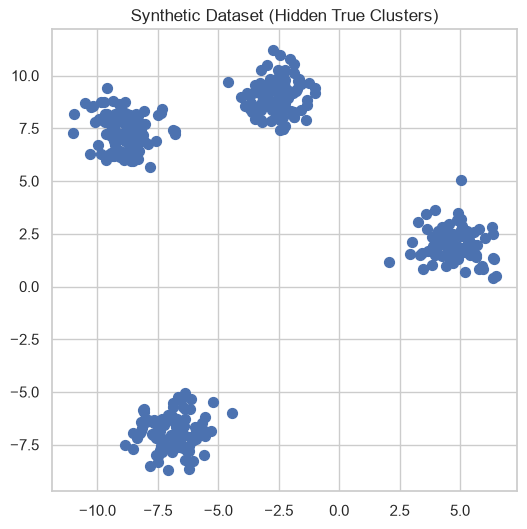

In [2]:
# Generating synthetic dataset (Well-separated clusters)
X, y_true = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Synthetic Dataset (Hidden True Clusters)")
plt.show()

In [3]:
X

array([[ -9.86267124,   8.72735826],
       [ -4.60499371,   9.67180813],
       [ -9.03492221,   7.10534406],
       [  5.41997462,   1.85552378],
       [  5.09659124,   2.8816222 ],
       [ -3.13580026,   8.75663692],
       [ -2.13060752,   8.956023  ],
       [ -8.42420054,   6.74292786],
       [ -2.43955997,   8.77508025],
       [  5.80079372,   2.74058634],
       [ -8.70163541,   7.17633625],
       [  3.89833446,   1.9255494 ],
       [ -7.33270816,   8.39985895],
       [  4.06763587,   2.51684788],
       [ -7.26971217,  -7.22615614],
       [ -6.84080989,  -7.54486969],
       [ -6.47889344,  -7.66215379],
       [ -2.60171625,   8.77340317],
       [  4.16838703,   2.65285136],
       [ -6.64780731,  -5.21978895],
       [  4.26233334,   2.84433016],
       [ -8.57742134,   6.32263205],
       [ -2.9447038 ,   9.1030242 ],
       [  2.04686496,   1.15365957],
       [ -2.66308639,   9.255524  ],
       [ -9.47070732,   7.7006976 ],
       [ -6.54887927,  -5.37867294],
 

In [4]:
# Fitting K-Means with optimal K=4
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

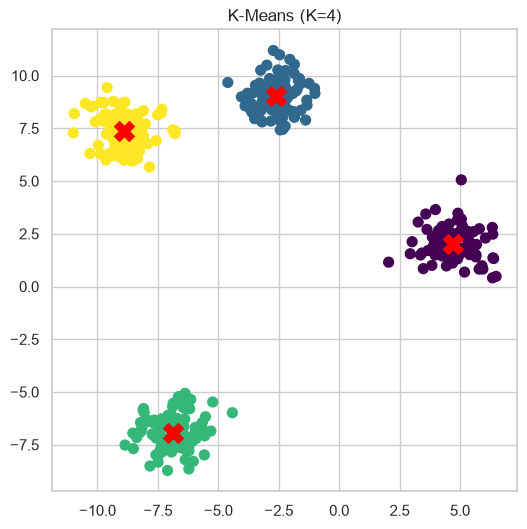

In [5]:
# Visualizing K-Means results (K=4)
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap="viridis", s=50)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            c="red", s=200, marker="X")
plt.title("K-Means (K=4)")
plt.show()

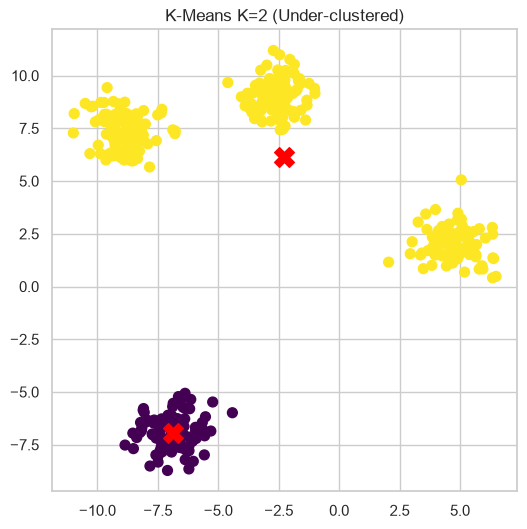

In [6]:
# Evaluating incorrect K: Under-clustering (K=2)
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters2 = kmeans2.fit_predict(X)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters2, cmap="viridis", s=50)
plt.scatter(kmeans2.cluster_centers_[:, 0],
            kmeans2.cluster_centers_[:, 1],
            c="red", s=200, marker="X")
plt.title("K-Means K=2 (Under-clustered)")
plt.show()

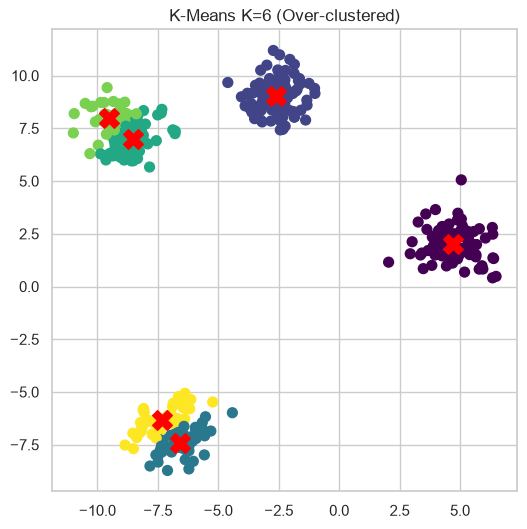

In [7]:
# Evaluating incorrect K: Over-clustering (K=6)
kmeans6 = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters6 = kmeans6.fit_predict(X)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters6, cmap="viridis", s=50)
plt.scatter(kmeans6.cluster_centers_[:, 0],
            kmeans6.cluster_centers_[:, 1],
            c="red", s=200, marker="X")
plt.title("K-Means K=6 (Over-clustered)")
plt.show()

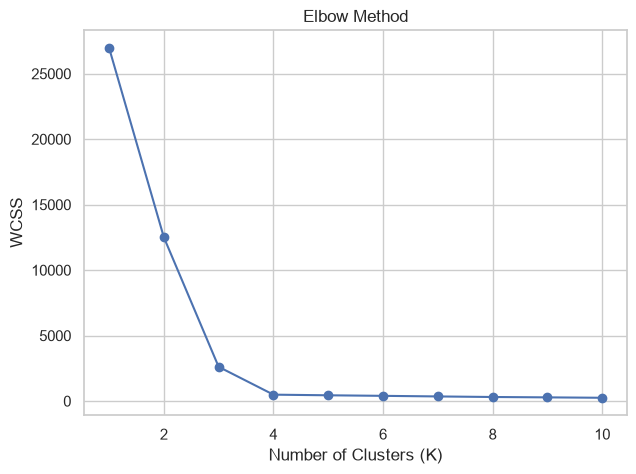

In [8]:
# Systematic K Selection: Elbow Method using WCSS
wcss = []  # Within-Cluster Sum of Squares

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [9]:
# Evaluating Silhouette Scores across different K values
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.604
K=3, Silhouette Score=0.779
K=4, Silhouette Score=0.835
K=5, Silhouette Score=0.724
K=6, Silhouette Score=0.584
K=7, Silhouette Score=0.454


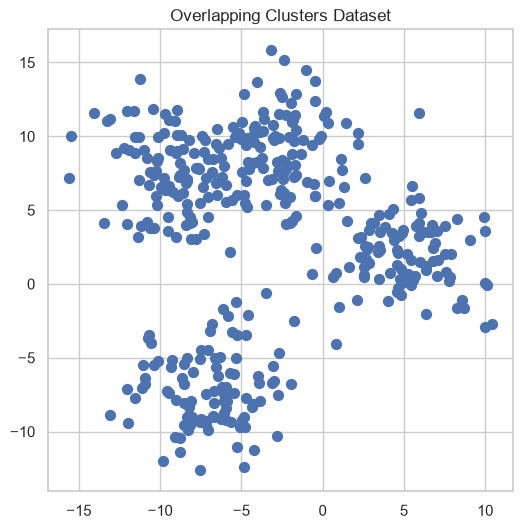

In [10]:
# Generating overlapping/complex clusters dataset
X_overlap, _ = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=2.5,
    random_state=42
)

plt.figure(figsize=(6, 6))
plt.scatter(X_overlap[:, 0], X_overlap[:, 1], s=50)
plt.title("Overlapping Clusters Dataset")
plt.show()

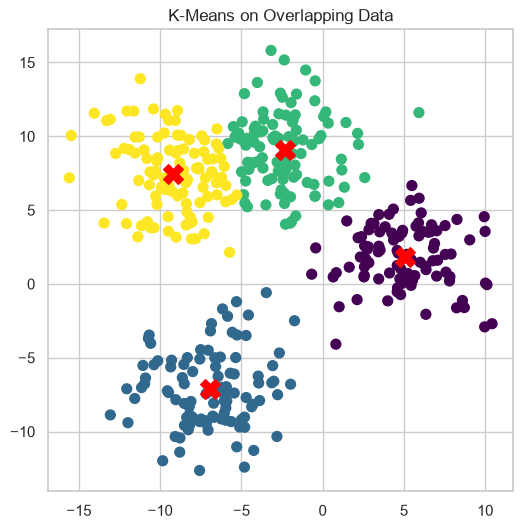

In [11]:
# Applying K-Means on overlapping dataset
kmeans_overlap = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_overlap = kmeans_overlap.fit_predict(X_overlap)

plt.figure(figsize=(6, 6))
plt.scatter(X_overlap[:, 0], X_overlap[:, 1], c=labels_overlap, cmap="viridis", s=50)
plt.scatter(kmeans_overlap.cluster_centers_[:, 0],
            kmeans_overlap.cluster_centers_[:, 1],
            c="red", s=200, marker="X")
plt.title("K-Means on Overlapping Data")
plt.show()

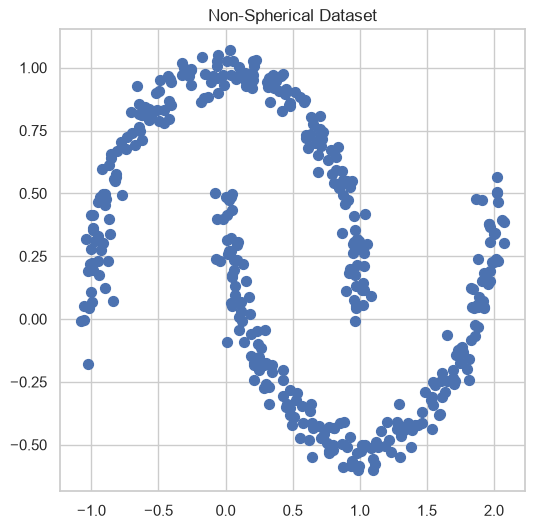

In [12]:
# Generating non-spherical dataset (Moons dataset)
X_moon, _ = make_moons(n_samples=400, noise=0.05, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(X_moon[:, 0], X_moon[:, 1], s=50)
plt.title("Non-Spherical Dataset")
plt.show()

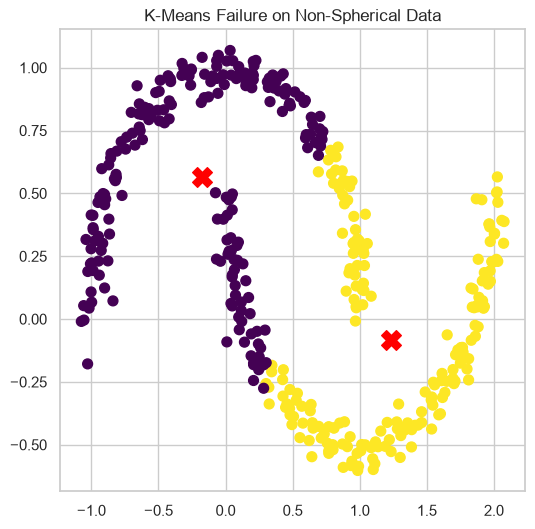

In [15]:
# K-Means performance on non-spherical data
kmeans_moon = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_moon = kmeans_moon.fit_predict(X_moon)

plt.figure(figsize=(6, 6))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels_moon, cmap="viridis", s=50)
plt.scatter(kmeans_moon.cluster_centers_[:, 0],
            kmeans_moon.cluster_centers_[:, 1],
            c="red", s=200, marker="X")
plt.title("K-Means Failure on Non-Spherical Data")
plt.show()

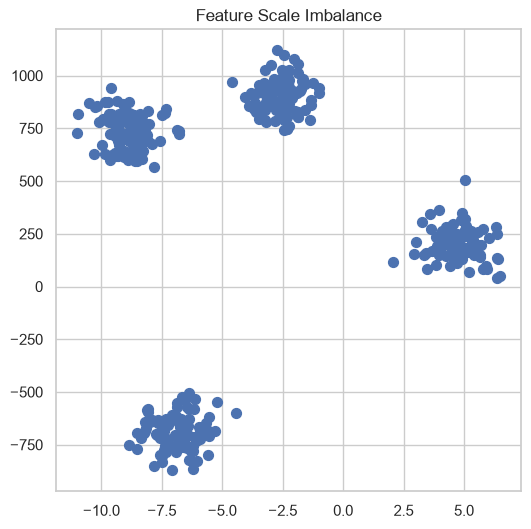

In [17]:
# Demonstrating the importance of Feature Scaling
X_scaled_problem = X.copy()
X_scaled_problem[:, 1] = X_scaled_problem[:, 1] * 100

plt.figure(figsize=(6, 6))
plt.scatter(X_scaled_problem[:, 0], X_scaled_problem[:, 1], s=50)
plt.title("Feature Scale Imbalance")
plt.show()

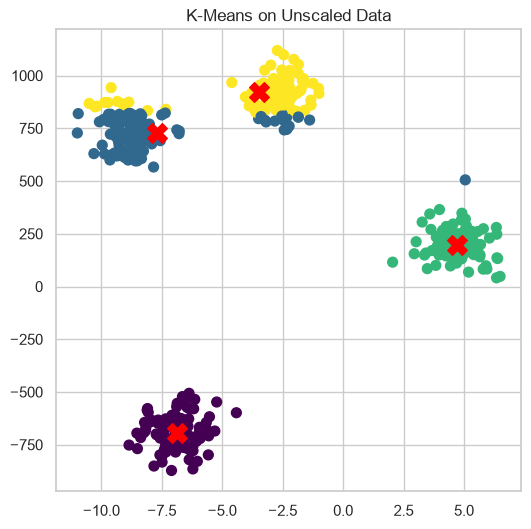

In [18]:
# Applying K-Means without Feature Scaling
km_no_scale = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_no_scale = km_no_scale.fit_predict(X_scaled_problem)

plt.figure(figsize=(6, 6))
plt.scatter(X_scaled_problem[:, 0], X_scaled_problem[:, 1],
            c=labels_no_scale, cmap="viridis", s=50)
plt.scatter(km_no_scale.cluster_centers_[:, 0],
            km_no_scale.cluster_centers_[:, 1],
            c="red", s=200, marker="X")
plt.title("K-Means on Unscaled Data")
plt.show()

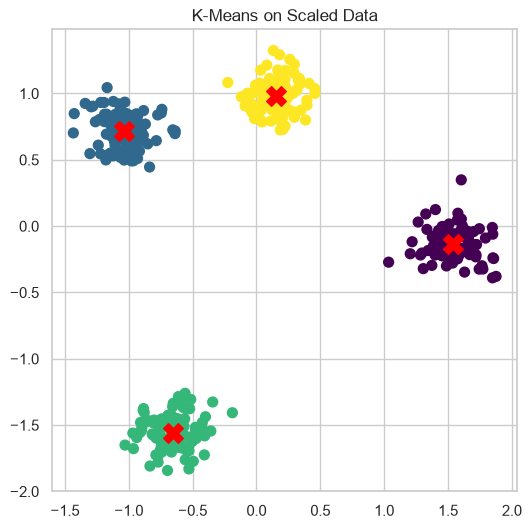

In [19]:
# Applying K-Means with StandardScaler
scaler = StandardScaler()
X_corrected = scaler.fit_transform(X_scaled_problem)

km_scaled = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_scaled = km_scaled.fit_predict(X_corrected)

plt.figure(figsize=(6, 6))
plt.scatter(X_corrected[:, 0], X_corrected[:, 1],
            c=labels_scaled, cmap="viridis", s=50)
plt.scatter(km_scaled.cluster_centers_[:, 0],
            km_scaled.cluster_centers_[:, 1],
            c="red", s=200, marker="X")

plt.title("K-Means on Scaled Data")
plt.show()